In [70]:
import os, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from skimage.filters import threshold_otsu, threshold_multiotsu
from skimage.feature import blob_dog
from skimage.segmentation import morphological_chan_vese, find_boundaries
from skimage.morphology import (remove_small_objects, remove_small_holes, binary_opening,
                                binary_closing, binary_dilation, convex_hull_image, disk)
from skimage.measure import label, regionprops
from scipy.ndimage import binary_fill_holes, distance_transform_edt
warnings.filterwarnings("ignore")

In [71]:
DATASET_DIR = "/Users/mariyamafnan/Documents/MVI/Dataset_BUSI_with_GT"
RANDOM_STATE = 42
WORK_SIZE = 256   # set None for native resolution

# Fixed evaluation set (no random draw). Benign + malignant only — normals
# excluded as they contain no lesion mask (standard BUSI segmentation practice).
IMAGES = {
    "benign":    [2,6,10,17,23,26,33,38,45,51,67,76,87,96,109,113,105,118,123,136,148,168,186,190,208,231,238,255,264,295,307,319,390,339,385,419,425,434],
    "malignant": [2,17,15,28,31,34,48,55,66,72,94,100,110,143,196,175,209],
}

In [72]:
def load_image_and_mask(class_name, index, dataset_dir=DATASET_DIR):
    img_path = os.path.join(dataset_dir, class_name, f"{class_name} ({index}).png")
    mask_path = os.path.join(dataset_dir, class_name, f"{class_name} ({index})_mask.png")
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if image is None or mask is None:
        raise FileNotFoundError
    mask = (mask > 127).astype(np.uint8)
    if WORK_SIZE is not None:
        image = cv2.resize(image, (WORK_SIZE, WORK_SIZE), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (WORK_SIZE, WORK_SIZE), interpolation=cv2.INTER_NEAREST)
    return image, mask

def preprocess(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)
    image = cv2.bilateralFilter(image, d=9, sigmaColor=50, sigmaSpace=50)
    image = cv2.medianBlur(image, 5)
    return image

def compute_adaptive_tolerance(image, seed, window=25):
    x, y = seed; h, w = image.shape
    x1, x2 = max(0, x - window), min(w, x + window)
    y1, y2 = max(0, y - window), min(h, y + window)
    roi = image[y1:y2, x1:x2]
    return int(np.clip(0.8 * np.std(roi) + 15, 15, 30))

In [73]:
def region_growing_with_edges(image, seed, intensity_tolerance, max_region_size, canny_low=30, canny_high=90):
    h, w = image.shape; sx, sy = seed
    visited = np.zeros((h, w), dtype=bool); mask = np.zeros((h, w), dtype=np.uint8)
    edges = cv2.Canny(image, canny_low, canny_high)
    q = deque([(sx, sy)]); visited[sy, sx] = True
    region_sum = float(image[sy, sx]); region_pixels = 1
    neighbours = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    while q:
        if region_pixels >= max_region_size: break
        x, y = q.popleft(); mask[y, x] = 1; mean = region_sum / region_pixels
        for dx, dy in neighbours:
            nx, ny = x + dx, y + dy
            if nx < 0 or ny < 0 or nx >= w or ny >= h or visited[ny, nx]: continue
            visited[ny, nx] = True
            if edges[ny, nx] != 0: continue
            if abs(float(image[ny, nx]) - mean) <= intensity_tolerance:
                mask[ny, nx] = 1; q.append((nx, ny)); region_sum += image[ny, nx]; region_pixels += 1
    return mask

In [74]:
def _clean(mask):
    mask = binary_opening(mask, disk(2)); mask = binary_closing(mask, disk(3))
    return binary_fill_holes(mask)

def pick_largest_region(mask, min_size=100):
    labeled = label(mask); regions = [r for r in regionprops(labeled) if r.area >= min_size]
    if not regions: return np.zeros_like(mask, dtype=np.uint8)
    best = max(regions, key=lambda r: r.area)
    return (labeled == best.label).astype(np.uint8)

In [75]:
def generate_candidates(den):
    h, w = den.shape; cands = []
    try:
        t = threshold_multiotsu(den, classes=3)
        for mk in [den < t[0], den < t[1]]:
            mk = _clean(mk); mk = remove_small_objects(mk, min_size=int(0.002 * h * w))
            lab = label(mk)
            for r in regionprops(lab): cands.append(lab == r.label)
    except Exception:
        mk = _clean(den < threshold_otsu(den))
        lab = label(remove_small_objects(mk, min_size=int(0.002 * h * w)))
        for r in regionprops(lab): cands.append(lab == r.label)
    inv = cv2.GaussianBlur((255 - den).astype(float) / 255.0, (0, 0), 2); mn = min(h, w)
    blobs = blob_dog(inv, min_sigma=mn * 0.03, max_sigma=mn * 0.18, threshold=0.05)
    for b in sorted(blobs, key=lambda b: -b[2])[:4]:
        y, x = int(b[0]), int(b[1])
        if not (0 <= y < h and 0 <= x < w): continue
        tol = compute_adaptive_tolerance(den, (x, y))
        raw = region_growing_with_edges(den, (x, y), tol, int(0.15 * h * w), 30, 90)
        mk = _clean(raw.astype(bool))
        if mk.sum() > 0: cands.append(mk)
    return cands

def _region_score(den, C):
    h, w = den.shape; C = C.astype(bool); area = C.sum()
    if area < int(0.002 * h * w) or area > 0.30 * h * w: return -1e9
    rp = regionprops(C.astype(int))[0]
    ring = binary_dilation(C, disk(12)) & ~C
    if ring.sum() == 0: return -1e9
    interior = den[C].mean(); rim = den[ring].mean()
    contrast = (rim - interior) / 255.0
    cy0, cx0 = h / 2.0, w / 2.0; diag = (h * h + w * w) ** 0.5; cy, cx = rp.centroid
    centrality = 1.0 - (((cx - cx0) ** 2 + (cy - cy0) ** 2) ** 0.5 / diag)
    area_norm = min(area / (0.06 * h * w), 1.0)
    return 1.8 * contrast + 0.7 * rp.solidity + 0.4 * area_norm + 0.3 * centrality

def select_best_region(den):
    cands = generate_candidates(den)
    if not cands: return None, None
    scored = [(_region_score(den, c), c) for c in cands]
    best_score, best = max(scored, key=lambda t: t[0])
    if best_score <= -1e8: return None, None
    comp = best.astype(np.uint8)
    dt = cv2.distanceTransform(comp, cv2.DIST_L2, 5)
    y, x = np.unravel_index(np.argmax(dt), dt.shape)
    return best, (int(x), int(y))

In [76]:
def postprocess_no_shape_bias(binary_mask, original_image, min_size=200, snake_iterations=40, margin=30, use_convex_hull=True):
    mask = _clean(binary_mask.astype(bool)); ys, xs = np.where(mask)
    if len(xs) == 0: return np.zeros_like(mask, dtype=np.uint8)
    rough = mask.sum(); h, w = original_image.shape
    x1, x2 = max(0, xs.min() - margin), min(w, xs.max() + margin)
    y1, y2 = max(0, ys.min() - margin), min(h, ys.max() + margin)
    refined = morphological_chan_vese(original_image[y1:y2, x1:x2], num_iter=snake_iterations,
                                      init_level_set=mask[y1:y2, x1:x2], smoothing=3)
    full = np.zeros_like(mask, dtype=bool); full[y1:y2, x1:x2] = refined
    if full.sum() > rough * 2: full = mask
    full = binary_fill_holes(full); full = remove_small_objects(full, min_size=min_size)
    full = remove_small_holes(full, area_threshold=min_size)
    if use_convex_hull and full.sum() > 0:
        pre = full.sum(); hulled = convex_hull_image(full)
        if hulled.sum() <= pre * 1.5: full = hulled
    return pick_largest_region(full.astype(np.uint8), min_size=min_size)

In [77]:
def dice_score(pred_mask, gt_mask, smooth=1e-6):
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    if gt.sum() == 0: return 1.0 if pred.sum() == 0 else 0.0
    inter = np.logical_and(pred, gt).sum()
    return (2 * inter + smooth) / (pred.sum() + gt.sum() + smooth)

def iou_score(pred_mask, gt_mask, smooth=1e-6):
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    if gt.sum() == 0: return 1.0 if pred.sum() == 0 else 0.0
    inter = np.logical_and(pred, gt).sum(); union = np.logical_or(pred, gt).sum()
    return (inter + smooth) / (union + smooth)

def pixel_accuracy(pred_mask, gt_mask):
    return float(np.mean(pred_mask.astype(bool) == gt_mask.astype(bool)))

def hd95(pred_mask, gt_mask):
    pred, gt = pred_mask.astype(bool), gt_mask.astype(bool)
    if pred.sum() == 0 and gt.sum() == 0: return 0.0
    if pred.sum() == 0 or gt.sum() == 0: return float('nan')
    pb = find_boundaries(pred, mode='inner'); gb = find_boundaries(gt, mode='inner')
    dt_to_g = distance_transform_edt(~gb); dt_to_p = distance_transform_edt(~pb)
    d = np.concatenate([dt_to_g[pb], dt_to_p[gb]])
    return float(np.percentile(d, 95))

In [78]:
def run_pipeline_segmentation(image, precomputed=None):
    if precomputed is None:
        den = preprocess(image); best_mask, seed = select_best_region(den)
    else:
        den, best_mask, seed = precomputed
    if best_mask is None:
        return np.zeros(image.shape[:2], dtype=np.uint8)
    return postprocess_no_shape_bias(best_mask.astype(np.uint8), den,
                                     min_size=200, snake_iterations=40, margin=30)

def build_sample():
    sample = {c: list(IMAGES.get(c, [])) for c in ("benign", "malignant")}
    counts = {c: len(sample[c]) for c in sample}
    return sample, counts

def precompute_selections(sample_indices):
    records = []
    for cls, indices in sample_indices.items():
        for idx in indices:
            try:
                image, gt = load_image_and_mask(cls, idx)
            except FileNotFoundError:
                continue
            den = preprocess(image)
            best_mask, seed = select_best_region(den)
            if seed is None: seed = (den.shape[1] // 2, den.shape[0] // 2)
            records.append({"class": cls, "index": idx, "image": image, "gt": gt,
                            "den": den, "best_mask": best_mask, "seed": seed})
    return records

In [79]:
sample, counts = build_sample()
print("Images per class:", counts)
records = precompute_selections(sample)

rows = []
for rec in records:
    cls, idx, gt = rec["class"], rec["index"], rec["gt"]
    pred = run_pipeline_segmentation(rec["image"],
                                     precomputed=(rec["den"], rec["best_mask"], rec["seed"]))
    d, j, hd, acc = dice_score(pred, gt), iou_score(pred, gt), hd95(pred, gt), pixel_accuracy(pred, gt)
    rows.append({"class": cls, "index": idx, "dice": round(d, 4), "iou": round(j, 4),
                 "hd95": (np.nan if np.isnan(hd) else round(hd, 2)), "pixel_acc": round(acc, 4)})

df = pd.DataFrame(rows)
pd.set_option("display.max_rows", None)
print("=============== PER-IMAGE METRICS ===============")
print(df.to_string(index=False))
print("\n=============== PER-CLASS MEANS ===============")
print(df.groupby("class")[["dice", "iou", "pixel_acc"]].mean().round(4))
print("\n=============== OVERALL ===============")
print(f"Images evaluated : {len(df)}")
print(f"Mean Dice        : {df.dice.mean():.4f}")
print(f"Mean IoU         : {df.iou.mean():.4f}")
print(f"Mean HD95        : {np.nanmean(df.hd95):.2f}")
print(f"Dice >= 0.85     : {(df.dice >= 0.85).sum()}/{len(df)}")
print(f"Dice >= 0.70     : {(df.dice >= 0.70).sum()}/{len(df)}")

df.to_csv(os.path.join(DATASET_DIR, "task1_per_image_metrics.csv"), index=False)
print("\nSaved per-image metrics CSV.")

Images per class: {'benign': 38, 'malignant': 17}
=============== PER-IMAGE METRICS ===============
    class  index   dice    iou  hd95  pixel_acc
   benign      2 0.9498 0.9044  3.13     0.9963
   benign      6 0.9140 0.8417  5.00     0.9950
   benign     10 0.9753 0.9518  3.00     0.9958
   benign     17 0.8984 0.8155  6.00     0.9963
   benign     23 0.9278 0.8653  5.00     0.9944
   benign     26 0.9453 0.8962  9.65     0.9857
   benign     33 0.7974 0.6630 29.49     0.9717
   benign     38 0.9540 0.9120  3.00     0.9979
   benign     45 0.9396 0.8862  9.64     0.9913
   benign     51 0.8711 0.7717  3.00     0.9978
   benign     67 0.5674 0.3960 52.36     0.7819
   benign     76 0.9335 0.8753  4.01     0.9975
   benign     87 0.8971 0.8134  5.00     0.9954
   benign     96 0.7506 0.6008 50.27     0.9154
   benign    109 0.9251 0.8607  8.00     0.9842
   benign    113 0.8906 0.8028 11.43     0.9907
   benign    105 0.8888 0.7999  7.17     0.9958
   benign    118 0.8905 0.8027  5.39

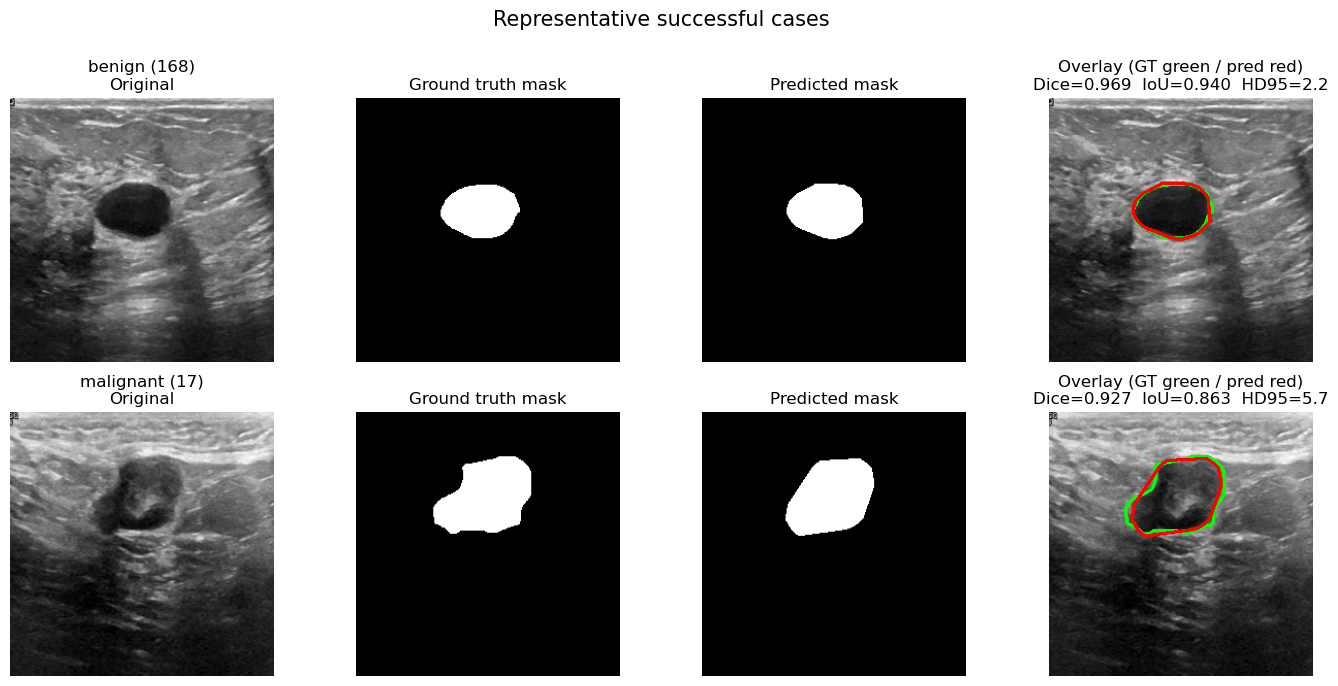

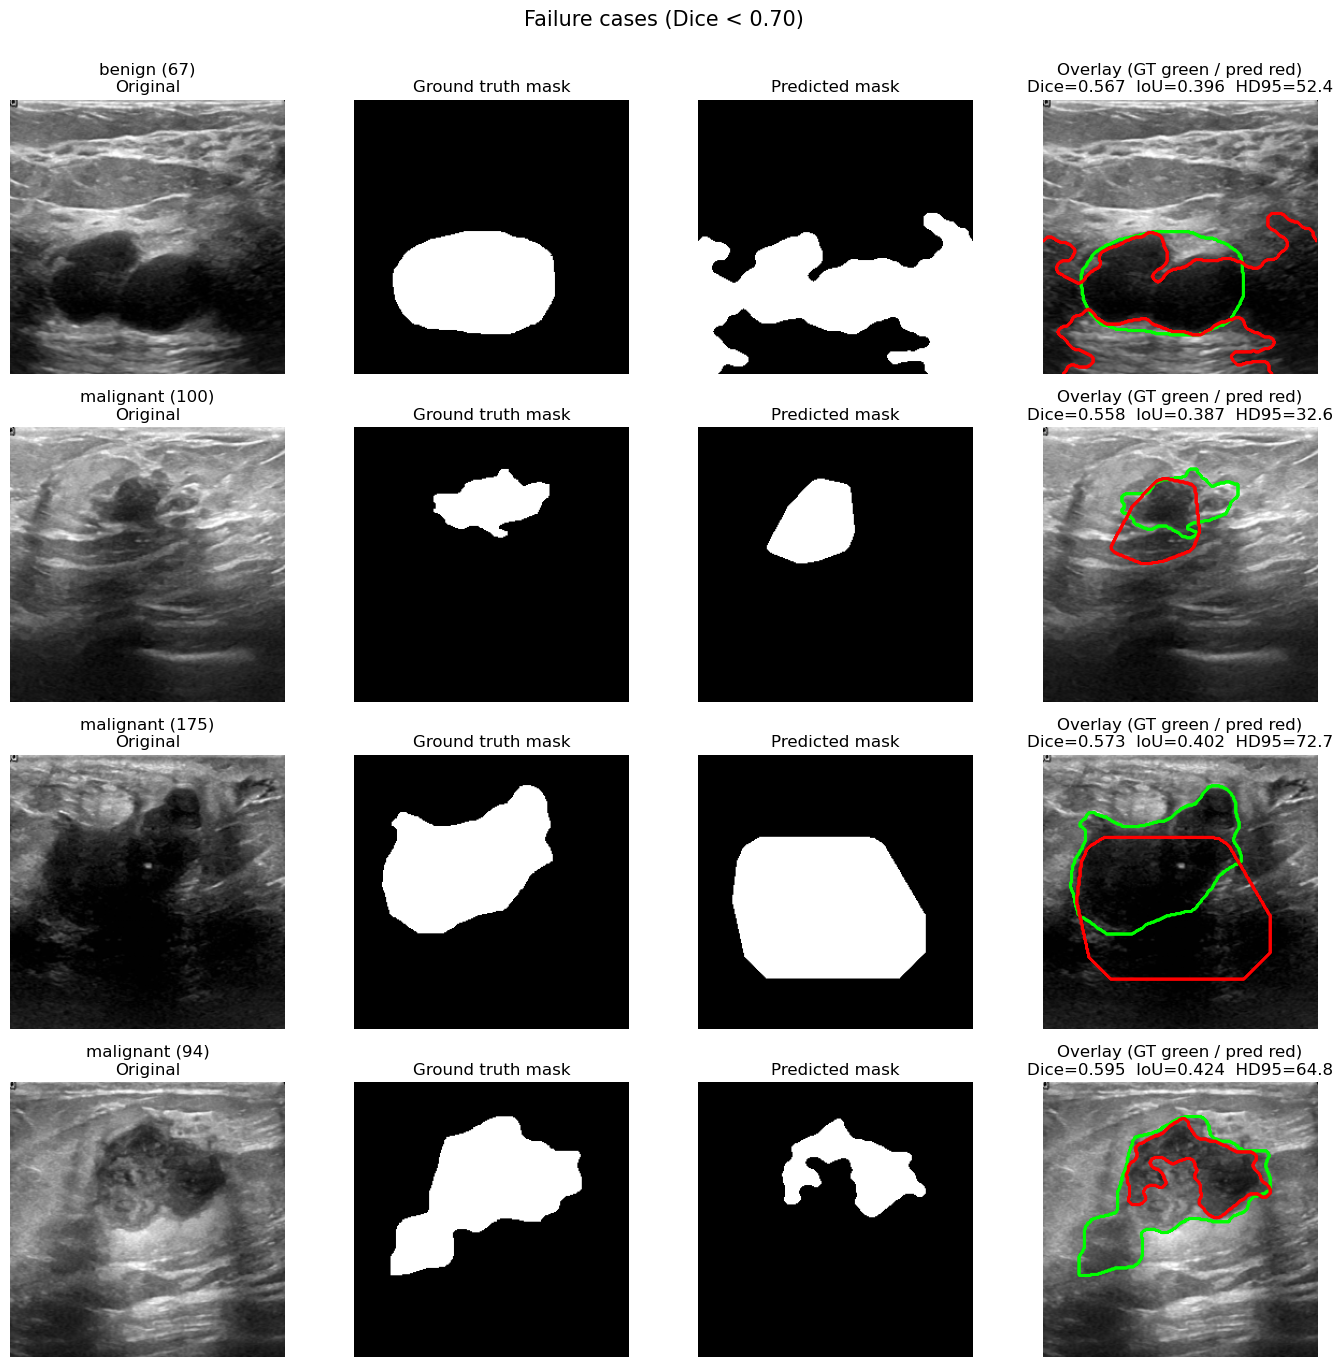

In [82]:
def show_cases(cases, title, fname):
    n = len(cases)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.4 * n))
    if n == 1: axes = axes[None, :]
    for row, (cls, idx) in zip(axes, cases):
        image, gt = load_image_and_mask(cls, idx)
        den = preprocess(image)
        best_mask, seed = select_best_region(den)
        pred = run_pipeline_segmentation(image, precomputed=(den, best_mask, seed))
        d, j, hd = dice_score(pred, gt), iou_score(pred, gt), hd95(pred, gt)
        hd_s = "nan" if np.isnan(hd) else f"{hd:.1f}"
        row[0].imshow(image, cmap="gray"); row[0].set_title(f"{cls} ({idx})\nOriginal")
        row[1].imshow(gt, cmap="gray");     row[1].set_title("Ground truth mask")
        row[2].imshow(pred, cmap="gray");   row[2].set_title("Predicted mask")
        row[3].imshow(image, cmap="gray")
        row[3].contour(gt, colors="lime", linewidths=1.5)
        if pred.sum() > 0: row[3].contour(pred, colors="red", linewidths=1.5)
        row[3].set_title(f"Overlay (GT green / pred red)\nDice={d:.3f}  IoU={j:.3f}  HD95={hd_s}")
        for ax in row: ax.axis("off")
    plt.suptitle(title, fontsize=15, y=1.002)
    plt.tight_layout()
    plt.savefig(f"{DATASET_DIR}/{fname}", dpi=200, bbox_inches="tight")
    plt.show()

show_cases([("benign", 168), ("malignant", 17)],
           "Representative successful cases", "task1_results_good.png")
show_cases([("benign", 67), ("malignant", 100), ("malignant", 175), ("malignant", 94)],
           "Failure cases (Dice < 0.70)", "task1_results_failures.png")

In [81]:
worst = df.sort_values("dice").head(10)
print("Worst-performing cases:")
print(worst.to_string(index=False))

Worst-performing cases:
    class  index   dice    iou  hd95  pixel_acc
malignant    100 0.5584 0.3873 32.62     0.9426
   benign     67 0.5674 0.3960 52.36     0.7819
malignant    175 0.5731 0.4016 72.67     0.7729
malignant     94 0.5954 0.4239 64.81     0.8831
   benign     96 0.7506 0.6008 50.27     0.9154
   benign    264 0.7701 0.6261 25.00     0.9655
malignant     34 0.7716 0.6282 16.93     0.9858
malignant     15 0.7730 0.6300 32.21     0.8743
   benign    255 0.7891 0.6516 21.89     0.9620
malignant    143 0.7914 0.6549 10.63     0.9838
